**NetID:** nr207489

*Names of students you worked with on this assignment:*
<!-- List names here, if applicable -->

::: {.callout-note}
This assignment falls under **Collaboration Mode 2: Individual Assignment &mdash; Collaboration Permitted**. Please refer to the syllabus for additional information.
:::

Instructions for all assignments can be found [here](https://github.com/Mase3206/csci547_ML/blob/main/assignments/_Assignment%20Instructions.ipynb).

Total points in the assignment add up to 90; an additional 10 points are allocated to presentation quality.

In [522]:
#| output: false
#| code-fold: true
#| code-summary: Initial environment setup

# Better type annotations
from __future__ import annotations

# MAC USERS TAKE NOTE:
# For clearer plots in Jupyter notebooks on Macs, run the following line of code:
%config InlineBackend.figure_format = 'retina'

# Set the base path
from pathlib import Path
BASE_PATH = Path('.').resolve()

## Learning Objectives

By successfully completing this assignment you will be able to...

- Explain the bias-variance tradeoff of supervised machine learning and the impact of model flexibility on algorithm performance
- Perform supervised machine learning training and performance evaluation
- Implement a k-nearest neighbors machine learning algorithm from scratch in a style similar to that of popular machine learning tools like `scikit-learn`
- Describe how KNN classification works, the method's reliance on distance measurements, and the impact of higher dimensionality on computational speed
- Apply regression (linear regression) and classification (KNN) supervised learning techniques to data and evaluate the performance of those methods
- Construct simple feature transformations for improving model fit in linear models
- Fit a `scikit-learn` supervised learning technique to training data and make predictions using it

# Conceptual Questions on Supervised Learning

## 1 - Model Flexibility

**\[4 points]**

For each part below, indicate whether we would generally expect the performance of a flexible statistical learning method to be *better* or *worse* than an inflexible method. Justify your answer.

1. The sample size $n$ is extremely large, and the number of predictors $p$ is small.
2. The number of predictors $p$ is extremely large, and the number of observations $n$ is small.
3. The relationship between the predictors and response is highly non-linear.
4. The variance of the error terms, i.e. $\sigma^2 = Var(\epsilon)$, is extremely high

**ANSWER**

1. A *flexible* learning method is likely better here, as it can use the large number of data points to improve its overall fit.
2. An *inflxible* learning method is likely better here, as the low quantity of data points is likely to cause higher variance. Inflexible methods are better suited for these sorts of applications than flexible ones, as the latter already tend to have higher variances.
3. A *flexible* learning method is best here, as inflexible methods (such as linear regression) will fit very poorly to the data.
4. An *inflexible* learning method is best here, as they are much better at dealing with data with high variance than inflexible methods, which can quickly overfit to the data.

## 2 - Preparatory Analysis

**\[6 points]**

For each of the following, **(i)** explain if each scenario is a classification or regression problem *and why*, **(ii)** indicate whether we are most interested in inference or prediction for that problem *and why*, and **(iii)** provide the sample size $n$ and number of predictors $p$ indicated for each scenario.

1. We collect a set of data on the top 500 firms in the US. For each firm we record profit, number of employees, industry and the CEO salary. We are interested in understanding which factors affect CEO salary.</li>
2. We are considering launching a new product and wish to know whether it will be a success or a failure. We collect data on 20 similar products that were previously launched. For each product we have recorded whether it was a success or failure, price charged for the product, marketing budget, competition price, and ten other variables.</li>
3. We are interesting in predicting the % change in the US dollar in relation to the weekly changes in the world stock markets. Hence we collect weekly data for all of 2012. For each week we record the % change in the dollar, the % change in the US market, the % change in the British market, and the % change in the German market.</li>

**ANSWER**

#### 2.1

<ol type="i">
    <li>This is a regression problem, as we are attempting to learn how one continuous output variable is affected by three continuous input variables.</li>
    <li>We are interested in inference, not prediction, as we are not trying to predict the salary of a CEO given certain inputs.</li>
    <li>$n=500$, $p=3$</li>
</ol>

#### 2.2

<ol type="i">
    <li>Binary classification: success or failure. The output is not continuous.</li>
    <li>We are interested in prediction, as we are using data from other similar products to attempt to predict the market performance of our own.</li>
    <li>$n=20$, $p=13$</li>
</ol>

#### 2.3

<ol type="i">
    <li>Regression, as the output variable is continuous, not binary.</li>
    <li>Prediction, as we are attempting to use previous data to predict the future.</li>
    <li>$n=52$, $p=3$</li>
</ol>

# Practical Questions

## 3 - Classification using KNN

**\[6 points]**

The table below provides a training dataset containing six observations (a.k.a. samples) ($n=6$) each with three predictors (a.k.a. features) ($p=3$), and one qualitative response variable (a.k.a. target).

| Obs.  | $x_1$ | $x_2$ | $x_3$ | $y$   |
|-------|-------|-------|-------|-------|
| **1** |  0    | 3     | 0     | Red   |
| **2** |  2    | 0     | 0     | Red   |
| **3** |  0    | 1     | 3     | Red   |
| **4** |  0    | 1     | 2     | Blue  |
| **5** | -1    | 0     | 1     | Blue  |
| **6** |  1    | 1     | 1     | Red   |

: Table 1. Training dataset with $n=6$ observations in $p=3$ dimensions with a categorical response, $y$ {.table-narrow}

We want to use the above training dataset to make a prediction, $\hat{y}$, for an unlabeled test data observation where $x_1=x_2=x_3=0$ using $K$-nearest neighbors. You are given some code below to get you started.

::: {.callout-note}
Coding is only required for part **(a)**, for **(b)** through **(d)**, please provide your reasoning based on your answer to part **(a)**.
:::

a. Compute the Euclidean distance between each observation and the test point, $x_1=x_2=x_3=0$. Present your answer in a table similar in style to Table 1 with observations 1-6 as the row headers.
b. What is our prediction, $\hat{y}$, when $K=1$ for the test point? Why?
c. What about when $K=3$ for the test point? Why?
d. If the Bayes decision boundary (the optimal decision boundary) in this problem is highly nonlinear, then would we expect the *best* value of $K$ to be large or small? Why?

In [2]:
import numpy as np

X = np.array([
    [ 0, 3, 0],
    [ 2, 0, 0],
    [ 0, 1, 3],
    [ 0, 1, 2],
    [-1, 0, 1],
    [ 1, 1, 1]
])
y = np.array(['r','r','r','b','b','r'])

**ANSWER**:

#### 3a

In [524]:
# Requires at least Python 3.10
number = float | int

import pandas as pd

points = np.vstack([X, [0, 0, 0]])
points


def euclidian_distance(
    point_1: tuple[number, ...],
    point_2: tuple[number, ...],
    precision: int = 5,
):
    s = 0
    for a, b in zip(point_1, point_2):
        s += (a - b) ** 2

    return round(np.sqrt(s), precision)

# distances = [euclidian_distance(p) for p in points]

distances = []
for p1 in points:
    r = []
    for p2 in points:
        r.append(euclidian_distance(p1, p2))
    distances.append(r)

distances
distances = np.column_stack([
    distances,
    ['Red', 'Red', 'Red', 'Blue', 'Blue', 'Red', ''],
])

# distances.append(euclidian_distance((0, 0, 0)))
df = pd.DataFrame(
    data=distances,
    columns=[*range(1, 7), "test point", "Color"],
    
)
df
# df.insert(loc=df.shape[1], column="Eucl. Dist.", value=distances)
df.index += 1

# Point 7 is the test point.
df.style.set_caption("<b>3.2:</b> Euclidean distances between each observation")\
    .set_table_attributes('class="table-narrow"')

,1,2,3,4,5,6,test point,Color
1,0.0,3.60555,3.60555,2.82843,3.31662,2.44949,3.0,Red
2,3.60555,0.0,3.74166,3.0,3.16228,1.73205,2.0,Red
3,3.60555,3.74166,0.0,1.0,2.44949,2.23607,3.16228,Red
4,2.82843,3.0,1.0,0.0,1.73205,1.41421,2.23607,Blue
5,3.31662,3.16228,2.44949,1.73205,0.0,2.23607,1.41421,Blue
6,2.44949,1.73205,2.23607,1.41421,2.23607,0.0,1.73205,Red
7,3.0,2.0,3.16228,2.23607,1.41421,1.73205,0.0,


#### 3b

When $K=1$, our prediction $\hat y$ for the test point $(0, 0, 0)$ is **Blue**, as observation 5 is the closest to the test point.

#### 3c

When $K=3$, our prediction $\hat y$ for the test point $(0, 0, 0)$ is **Red**, as its three nearest neighbors, observations 5, 6, and 2, are Blue, Red, and Red, respectively.

#### 3d

<!-- If the Bayes decision boundary (the optimal decision boundary) in this problem is highly nonlinear, then would we expect the *best* value of $K$ to be large or small? Why? -->

We would expect the best value of $K$ to be small, as this allows the model to be more flexible, and thus more non-linear.

## 4 - Build your own classification algorithm

**\[18 points]**

a. Build a working version of a binary KNN classifier using the skeleton code below. We'll use the `sklearn` convention that a supervised learning algorithm has the methods `fit` which trains your algorithm (for KNN that means storing the data) and `predict` which identifies the K nearest neighbors and determines the most common class among those K neighbors.
b. Load the datasets to be evaluated here. Each includes training features ($\mathbf{X}$), and test features ($\mathbf{y}$) for both a low dimensional dataset ($p = 2$ features/predictors) and a higher dimensional dataset ($p = 100$ features/predictors). For each of these datasets there are $n=1000$ observations of each. They can be found in the [`data` subfolder in the `assignments` folder on GitHub](https://github.com/Mase3206/csci547_ML/tree/main/assignments/data). Each file is labeled similar to `A2_X_train_low.csv`, which lets you know whether the dataset is of features, $X$, targets, $y$; training or testing; and low or high dimensions.
c. Train your classifier on first the low dimensional dataset and then the high dimensional dataset with $k=5$. Evaluate the classification performance on the corresponding test data for each of those trained models. Calculate the time it takes each model to make the predictions and the overall accuracy of those predictions for each corresponding set of test data - state each.
d. Compare your implementation's accuracy and computation time to the scikit learn [KNeighborsClassifier](http://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html) class. How do the results and speed compare to your implementation?
e. Some supervised learning algorithms are more computationally intensive during training than testing. What are the drawbacks of the prediction process being slow? In what cases in practice might slow testing (inference) be more problematic than slow training?

::: {.callout-note title="Note for (a)"}
Most classification algorithms typically also have a method `predict_proba` which outputs the confidence score of each prediction, but we will explore that in a later assignment.
:::

Here's some skeleton code for part (a) to write your own KNN classifier:

In [12]:
#| output: false
#| code-fold: true
#| code-summary: Show skeleton code
class Knn:
# k-Nearest Neighbor class object for classification training and testing
    def __init__(self): ...
        
    def fit(self, x, y): ...
        # Save the training data to properties of this class
        
    def predict(self, x, k):
        y_hat = [] 
        # Variable to store the estimated class label for 
        # Calculate the distance from each vector in x to the training data
        
        # Return the estimated targets
        return y_hat

# Metric of overall classification accuracy
#  (a more general function, sklearn.metrics.accuracy_score, is also available)
def accuracy(y,y_hat):
    nvalues = len(y)
    accuracy = sum(y == y_hat) / nvalues
    return accuracy

**ANSWER**:

### 4a - Write my own KNN implementation

> Build a working version of a binary KNN classifier using the skeleton code below. We'll use the `sklearn` convention that a supervised learning algorithm has the methods `fit` which trains your algorithm (for KNN that means storing the data) and `predict` which identifies the K nearest neighbors and determines the most common class among those K neighbors.

In [525]:
from collections.abc import Iterable

# Yay, generic programming!
def most_common[T](items: Iterable[T]):
    return max(set(items), key=items.count)


class NdDict[T_val](dict[bytes, T_val]):
    '''
    Custom `dict` subclass which can "hash" `np.ndarray`s by converting them to
    `bytes` (which is hashable) and passing that into the parent `dict` class's
    `__setitem__` and `__getitem__` functions.
    '''
    def __setitem__(self, key: np.ndarray, value: T_val) -> None:
        if isinstance(key, np.ndarray):
            key = key.tobytes()
        return super().__setitem__(key, value)
    
    def __getitem__(self, key: np.ndarray) -> T_val:
        if isinstance(key, np.ndarray):
            key = key.tobytes()
        return super().__getitem__(key)


class KNN:
    '''
    K-Nearest Neighbor class for classification training and testing. Implemented
    methods are compatible with `sklearn.KNeighborsClassifier`.
    '''
    
    k: int
    x_train: np.ndarray
    y_train: np.ndarray
    
    
    def __init__(self, n_neighbors: int = 5):
        self.k = n_neighbors

    
    def fit(
        self,
        x: np.ndarray | pd.DataFrame,
        y: np.ndarray | pd.DataFrame,
    ) -> KNN:
        '''
        "Train" the KNN model by storing the given training data.

        Arguments
        ---------
            x (vector, np.ndarray) : Input features for training
            y (vector, np.ndarray) : Output classifications for training

        Returns
        -------
            (KNN) : This (now fit) KNN classifier
        '''

        if isinstance(x, pd.DataFrame):
            x = x.to_numpy()
        if isinstance(y, pd.DataFrame):
            y = y.to_numpy()
        
        self.x_train = x
        self.y_train = y

        return self
        

    def predict(self, x_test: np.ndarray | pd.DataFrame) -> np.ndarray:
        '''
        Calculate the Euclidean distances between each given point in `x_test`, and
        predict the category with the fit KNN classifier using those distances.

        Arguments
        ---------
            x_test (vector, np.ndarray) : Input features for testing

        Returns
        -------
            (vector, np.ndarray) : Predicted classifications
        '''

        if isinstance(x_test, pd.DataFrame):
            x_test = x_test.to_numpy()
        
        # For each distance, make note of the category of the training point. This
        # lets us sort later down the line while ensuring each distance remains
        # with its associated category.
        
        distances: NdDict[
            # test point, 
            list[
                tuple[  # training point
                    number,  # distance to training point
                    object  # category of training point
                ]
            ]
        ] = NdDict()
        
        for p1 in x_test:
            r = []
            for p2, y in zip(self.x_train, self.y_train):
                # (distance, category)
                r.append( (euclidian_distance(p1, p2), y) )
            distances[p1] = r

        
        y_hat = []

        for p, d in distances.items():
            # Sort by the distance
            d_sorted = sorted(d, key=(lambda v: v[0]))
            k_nearest = d_sorted[:self.k]
            y_hat.append(most_common([neighbor[1] for neighbor in k_nearest]))

        return np.array(y_hat)



def accuracy(y: np.ndarray ,y_hat: np.ndarray):
    '''
    Metric of overall classification accuracy. A more general function,
    `sklearn.metrics.accuracy_score`, is also available.
    '''
    return float(sum(y == y_hat) / len(y))

### 4b - Load the datasets

> Load the datasets to be evaluated here. Each includes training features ($\mathbf{X}$), and test features ($\mathbf{y}$) for both a low dimensional dataset ($p = 2$ features/predictors) and a higher dimensional dataset ($p = 100$ features/predictors). For each of these datasets there are $n=1000$ observations of each. They can be found in the [`data` subfolder in the `assignments` folder on GitHub](https://github.com/Mase3206/csci547_ML/tree/main/assignments/data). Each file is labeled similar to `A2_X_train_low.csv`, which lets you know whether the dataset is of features, $X$, targets, $y$; training or testing; and low or high dimensions.

In [529]:
#| output: false
from enum import StrEnum
from textwrap import dedent

class Dataset:
    '''
    Helpful class to make managing the sample datasets easier. Give it either
    "high" or "low", and it will use that to import `np.ndarray`s for the testing
    and training datasets for both X and Y from the CSV files in the 'data/'
    directory.
    '''
    
    feature_size: FeatureSize
    x_train: np.ndarray
    y_train: np.ndarray
    x_test: np.ndarray
    y_test: np.ndarray
    
    class FeatureSize(StrEnum):
        HIGH = 'high'
        LOW = 'low'
        
    def __init__(self, feature_size: FeatureSize):
        self.feature_size = feature_size
        data_fold = BASE_PATH / 'data'
        file = lambda var, div: f'A2_{var}_{div}_{str(feature_size)}.csv'

        self.x_train = np.genfromtxt(data_fold / file('X', 'train'), delimiter=',')
        self.y_train = np.genfromtxt(data_fold / file('y', 'train'), delimiter=',')
        self.x_test = np.genfromtxt(data_fold / file('X', 'test'), delimiter=',')
        self.y_test = np.genfromtxt(data_fold / file('y', 'test'), delimiter=',')

    def __repr__(self):
        return dedent(f'''\
        Dataset(
            feature_size={self.feature_size},
            x_train={self.x_train.shape},
            y_train={self.y_train.shape},
            x_test={self.x_test.shape},
            y_test={self.y_test.shape}
        )''')


set_low = Dataset('low')
set_high = Dataset('high')
set_low, set_high

(Dataset(
     feature_size=low,
     x_train=(1000, 2),
     y_train=(1000,),
     x_test=(1000, 2),
     y_test=(1000,)
 ),
 Dataset(
     feature_size=high,
     x_train=(1000, 100),
     y_train=(1000,),
     x_test=(1000, 100),
     y_test=(1000,)
 ))

### 4c - Using my KNN implementation

> Train your classifier on first the low dimensional dataset and then the high dimensional dataset with $k=5$. Evaluate the classification performance on the corresponding test data for each of those trained models. Calculate the time it takes each model to make the predictions and the overall accuracy of those predictions for each corresponding set of test data - state each.

In [97]:
import time

In [109]:
knn_low = KNN(5)
knn_low.fit(set_low.x_train, set_low.y_train)

my_knn_low_start = time.time()
y_low_hat = knn_low.predict(set_low.x_test)
my_knn_low_end = time.time()

In [133]:
#| echo: false
print('My KNN implementation with the "low" dataset')
print(f'Time elapsed: {(my_knn_low_time := my_knn_low_end - my_knn_low_start):.4f} sec')
print(f'Accuracy: {accuracy(set_low.y_test, y_low_hat)}')

My KNN implementation with the "low" dataset
Time elapsed: 3.5947 sec
Accuracy: 0.925


In [111]:
knn_high = KNN(5)
knn_high.fit(set_high.x_train, set_high.y_train)

my_knn_high_start = time.time()
y_high_hat = knn_high.predict(set_high.x_test)
my_knn_high_end = time.time()

In [134]:
#| echo: false
print('My KNN implementation with the "high" dataset')
print(f'Time elapsed: {(my_knn_high_time := my_knn_high_end - my_knn_high_start):.4f} sec')
print(f'Accuracy: {accuracy(set_high.y_test, y_high_hat)}')

My KNN implementation with the "high" dataset
Time elapsed: 19.3160 sec
Accuracy: 0.993


### 4d - Use SKLearn's KNN implementation
> Compare your implementation's accuracy and computation time to the scikit learn [KNeighborsClassifier](http://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html) class. How do the results and speed compare to your implementation?

In [112]:
from sklearn.neighbors import KNeighborsClassifier

In [114]:
sk_knn_low = KNeighborsClassifier(5)
sk_knn_low.fit(set_low.x_train, set_low.y_train)

sk_knn_low_start = time.time()
sk_y_low_hat = sk_knn_low.predict(set_low.x_test)
sk_knn_low_end = time.time()

In [131]:
#| echo: false
print('SKLearn\'s KNN implementation with the "low" dataset')
print(f'Time elapsed: {(sk_knn_low_time := sk_knn_low_end - sk_knn_low_start):.4f} sec')
print(f'{my_knn_low_time - sk_knn_low_time:.4f} sec faster than my KNN implementation')
print(f'Accuracy: {accuracy(set_low.y_test, sk_y_low_hat)}')

SKLearn's KNN implementation with the "low" dataset
Time elapsed: 0.0051 sec
3.5896 sec faster than my KNN implementation
Accuracy: 0.925


In [116]:
sk_knn_high = KNeighborsClassifier(5)
sk_knn_high.fit(set_high.x_train, set_high.y_train)

sk_knn_high_start = time.time()
sk_y_high_hat = sk_knn_high.predict(set_high.x_test)
sk_knn_high_end = time.time()

In [132]:
#| echo: false
print('SKLearn\'s KNN implementation with the "high" dataset')
print(f'Time elapsed: {(sk_knn_high_time := sk_knn_high_end - sk_knn_high_start):.4f} sec')
print(f'{my_knn_high_time - sk_knn_high_time:.4f} sec faster than my KNN implementation')
print(f'Accuracy: {accuracy(set_high.y_test, sk_y_high_hat)}')

SKLearn's KNN implementation with the "high" dataset
Time elapsed: 0.0145 sec
19.3015 sec faster than my KNN implementation
Accuracy: 0.993


### 4e - Faster learning or inference?

> Some supervised learning algorithms are more computationally intensive during training than testing. What are the drawbacks of the prediction process being slow? In what cases in practice might slow testing (inference) be more problematic than slow training?

With a slow-training algorithm, any changes to the input features (such as normalization) will take quite a bit of time to be applied, as the algorithm has to completely retrain itself with the (to its eyes) completely different data. 

A slow-testing algorithm is more problematic in an extremely time-sensitive environment. Take active defense systems for example. These systems may need to determine whether something flying overhead is friendly or a threat, and it needs to do it as fast as possible with *perfect* accuracy. Failure to do so in a short amount of time may lead to the system failing to do the one thing it was designed to do: protect people and assets. A slow-testing algorithm (such as KNN) would be a horrible fit for this sort of scenario.

## 5 - Bias-variance tradeoff
Exploring the tradeoff with a KNN classifier.

**\[20 points]** 

This exercise will illustrate the impact of the bias-variance tradeoff on classifier performance by investigating how model flexibility impacts classifier decision boundaries. For this problem, please use Scikit-learn's KNN implementation rather than your own implementation, as you did at the end of the last question.

a. Create a synthetic dataset (with both features and targets). Use the [`make_moons`](http://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html#sklearn.datasets.make_moons) module with the parameter `noise=0.35` to generate 1000 random samples.
b. Visualize your data: scatterplot your random samples with each class in a different color.
c. Create 3 different data subsets by selecting 100 of the 1000 data points at random three times (with replacement). For each of these 100-sample datasets, fit three separate k-Nearest Neighbor classifiers with: $k = \{1, 25, 50\}$. This will result in 9 combinations (3 datasets, each with 3 trained classifiers).
d. For each combination of dataset and trained classifier plot the decision boundary (similar in style to Figure 2.15 from *Introduction to Statistical Learning*). This should form a 3-by-3 grid. Each column should represent a different value of $k$ and each row should represent a different dataset.
e. What do you notice about the difference between the rows and the columns. Which decision boundaries appear to best separate the two classes of data? Which decision boundaries vary the most as the data change?
f. Explain the bias-variance tradeoff using the example of the plots you made in this exercise and its implications for training supervised machine learning algorithms.

**Notes and tips** for plotting decision boundaries (as in part **(d)**):

- Resource for plotting decision boundaries with meshgrid and contour: [https://scikit-learn.org/stable/auto_examples/neighbors/plot_classification.html](https://scikit-learn.org/stable/auto_examples/neighbors/plot_classification.html)
- If you would like to change the colors of the background, and do not like any of the existing cmap available in matplotlib, you can make your own cmap using the 2 sets of rgb values.
  Sample code (replace r, g, b with respective rgb values):
```python
from matplotlib.colors import LinearSegmentedColormap
newcmp = LinearSegmentedColormap.from_list(
    "new",
    [(r/255, g/255, b/255), (r/255, g/255, b/255)],
    N=2,
)
```

**ANSWER**

### 5a - Synthisize the data

> Create a synthetic dataset (with both features and targets). Use the [`make_moons`](http://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html#sklearn.datasets.make_moons) module with the parameter `noise=0.35` to generate 1000 random samples.

In [186]:
from sklearn.datasets import make_moons

moons_x, moons_y = make_moons(n_samples=1000, noise=0.35)

### 5b - Visualize your data

> Create a scatterplot of your random samples with each class in a different color.

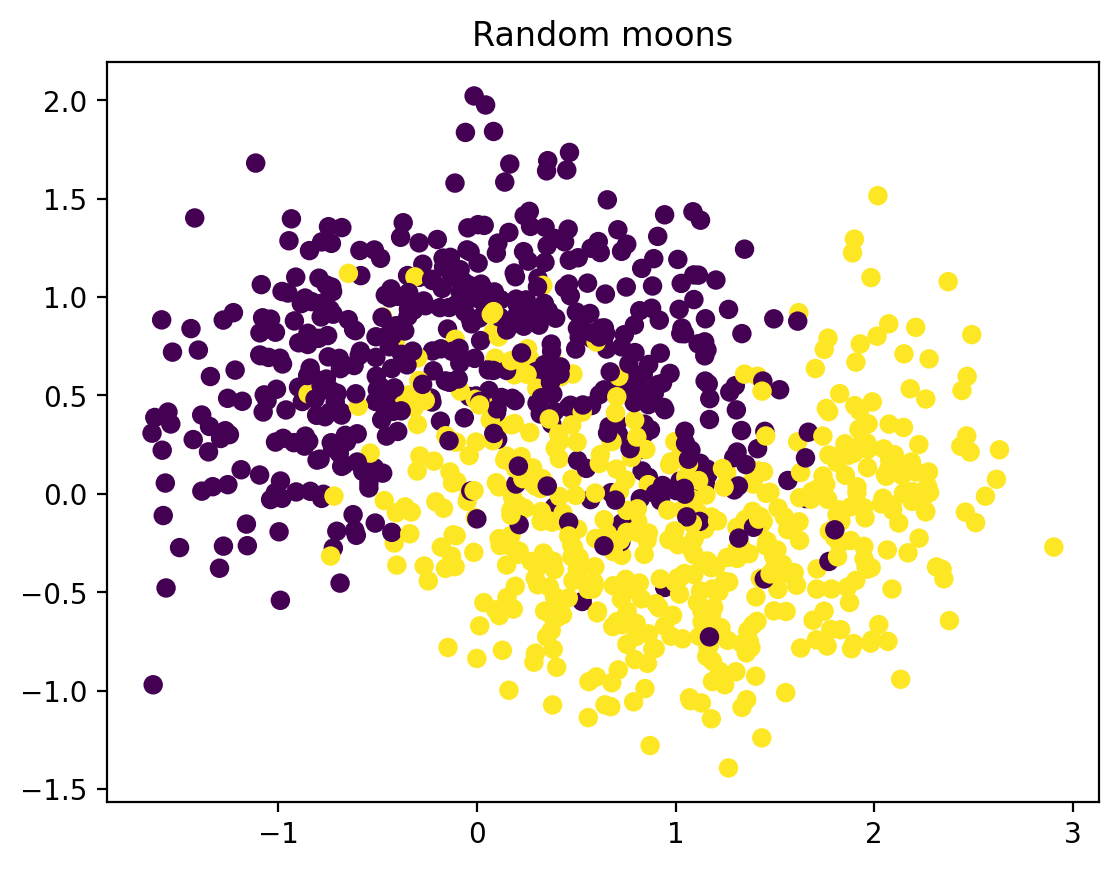

In [187]:
import matplotlib.pyplot as plt

plt.scatter(
    x=moons_x[:, 0],
    y=moons_x[:, 1],
    c=moons_y,
)
plt.title("Random moons")
plt.show()

### 5c - Create and fit three subsets

> Create 3 different data subsets by selecting 100 of the 1000 data points at random three times (with replacement). For each of these 100-sample datasets, fit three separate k-Nearest Neighbor classifiers with: $k = \{1, 25, 50\}$. This will result in 9 combinations (3 datasets, each with 3 trained classifiers).

In [277]:
# Generate the subsets

subsets = []
for i in range(3):
    indices = np.random.choice(moons_x.shape[0], size=100)
    subsets.append((
        moons_x[indices],
        moons_y[indices],
    ))

In [520]:
# Fit the KNN classifiers

classifiers = []

for subset in subsets:
    classifiers += [
        # KNeighborsClassifier(k).fit(subset.x_train, subset.y_train)
        KNeighborsClassifier(k).fit(subset[0], subset[1])
        for k in [1, 25, 50]
    ]

### 5d - Decision boundaries

> For each combination of dataset and trained classifier, plot the decision boundary (similar in style to Figure 2.15 from *Introduction to Statistical Learning*). This should form a 3-by-3 grid. Each column should represent a different value of $k$ and each row should represent a different dataset.

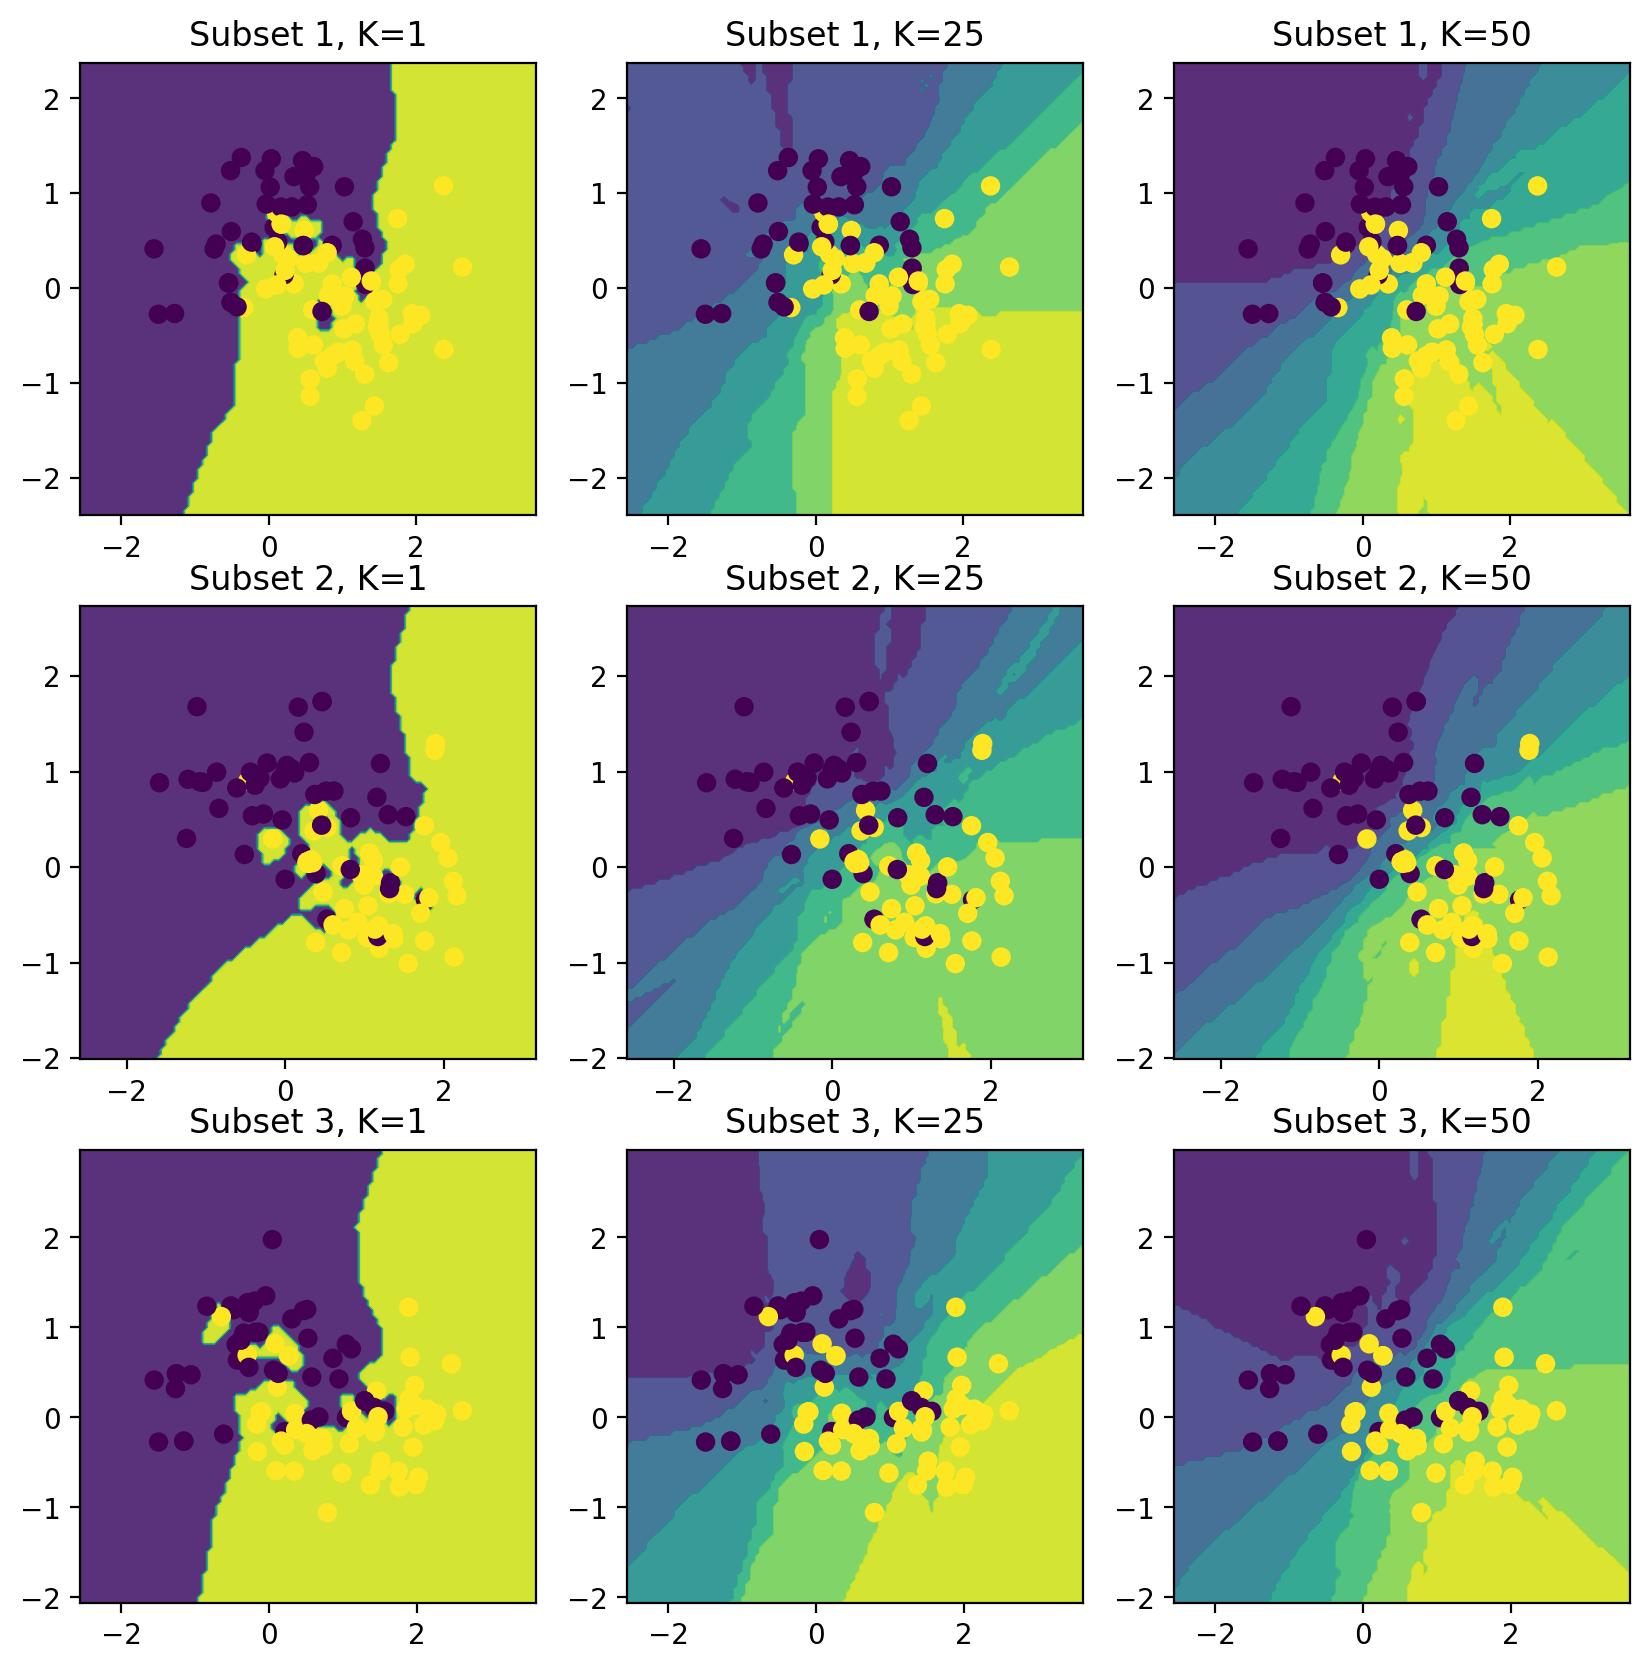

In [523]:
from sklearn.inspection import DecisionBoundaryDisplay

_, axes = plt.subplots(nrows=3, ncols=3, figsize=(10, 10))
axes = axes.flatten()

# _s = [*subsets[0] * 3, *subsets[1] * 3, *subsets[2] * 3]
_s = [
    subsets[0],
    subsets[0],
    subsets[0],
    subsets[1],
    subsets[1],
    subsets[1],
    subsets[2],
    subsets[2],
    subsets[2],
]
_i = [1, 1, 1, 2, 2, 2, 3, 3, 3]

for axis, classifier, subset, i in zip(axes, classifiers, _s, _i):
    disp = DecisionBoundaryDisplay.from_estimator(
        classifier,
        classifier._fit_X,
        alpha=0.9,
        ax=axis
    )
    scatter = disp.ax_.scatter(
        subset[0][:, 0],
        subset[0][:, 1],
        c=subset[1],
    )
    disp.ax_.set_title(f'Subset {i}, K={classifier.n_neighbors}')

plt.show()

### 5e - Visual analysis

> What do you notice about the difference between the rows and the columns?

Within each column, the general shape of the boundaries are quite similar. 

> Which decision boundaries appear to best separate the two classes of data?

The $K=25$ boundaries appear to have the best balance between over- and underfitting.

> Which decision boundaries vary the most as the data change?

The $K=1$ boundaries vary the most, which is expected, as they tend to strongly overfit to the data.

### 5f - Bias-variance tradeoff

> Explain the bias-variance tradeoff using the example of the plots you made in this exercise and its implications for training supervised machine learning algorithms.

With $K=1$, we have achieved a low bias, as the model is very overfit, so predictions are likely to be correctly categorized. This also has very high variance, as the boundary clearly changes significantly between each random subset. With $K=50$, we have achieved the opposite: high bias and low variance due to underfitting.

## 6 - Bias-variance trade-off, pt. 2
Quantifying the tradeoff.

**[18 points]** 

This exercise explores the impact of the bias-variance tradeoff on classifier performance by looking at the performance on both training and test data.

Here, the value of $k$ determines how flexible our model is.

a. Using the function created earlier to generate random samples (using the `make_moons` function setting the `noise` parameter to 0.35), create a new set of 1000 random samples, and call this dataset your test set and the previously created dataset your training set.
b. Train a kNN classifier on your training set for $k = 1,2,...500$. Apply each of these trained classifiers to both your training dataset and your test dataset and plot the classification error (fraction of incorrect predictions).
c. What trend do you see in the results?
d. What values of $k$ represent high bias and which represent high variance?
e. What is the optimal value of $k$ and why?
f. In KNN classifiers, the value of k controls the flexibility of the model - what controls the flexibility of other models?

**ANSWER**

### 6a - Make more moons!

> Using the function created earlier to generate random samples (using the `make_moons` function setting the `noise` parameter to 0.35), create a new set of 1000 random samples, and call this dataset your test set and the previously created dataset your training set.

In [280]:
moons_train_x = moons_x
moons_train_y = moons_y

moons_test_x, moons_test_y = make_moons(n_samples=1000, noise=0.35)

### 6b - Train train train...

> Train a kNN classifier on your training set for $k = 1,2,...500$. Apply each of these trained classifiers to both your training dataset and your test dataset and plot the classification error (fraction of incorrect predictions).

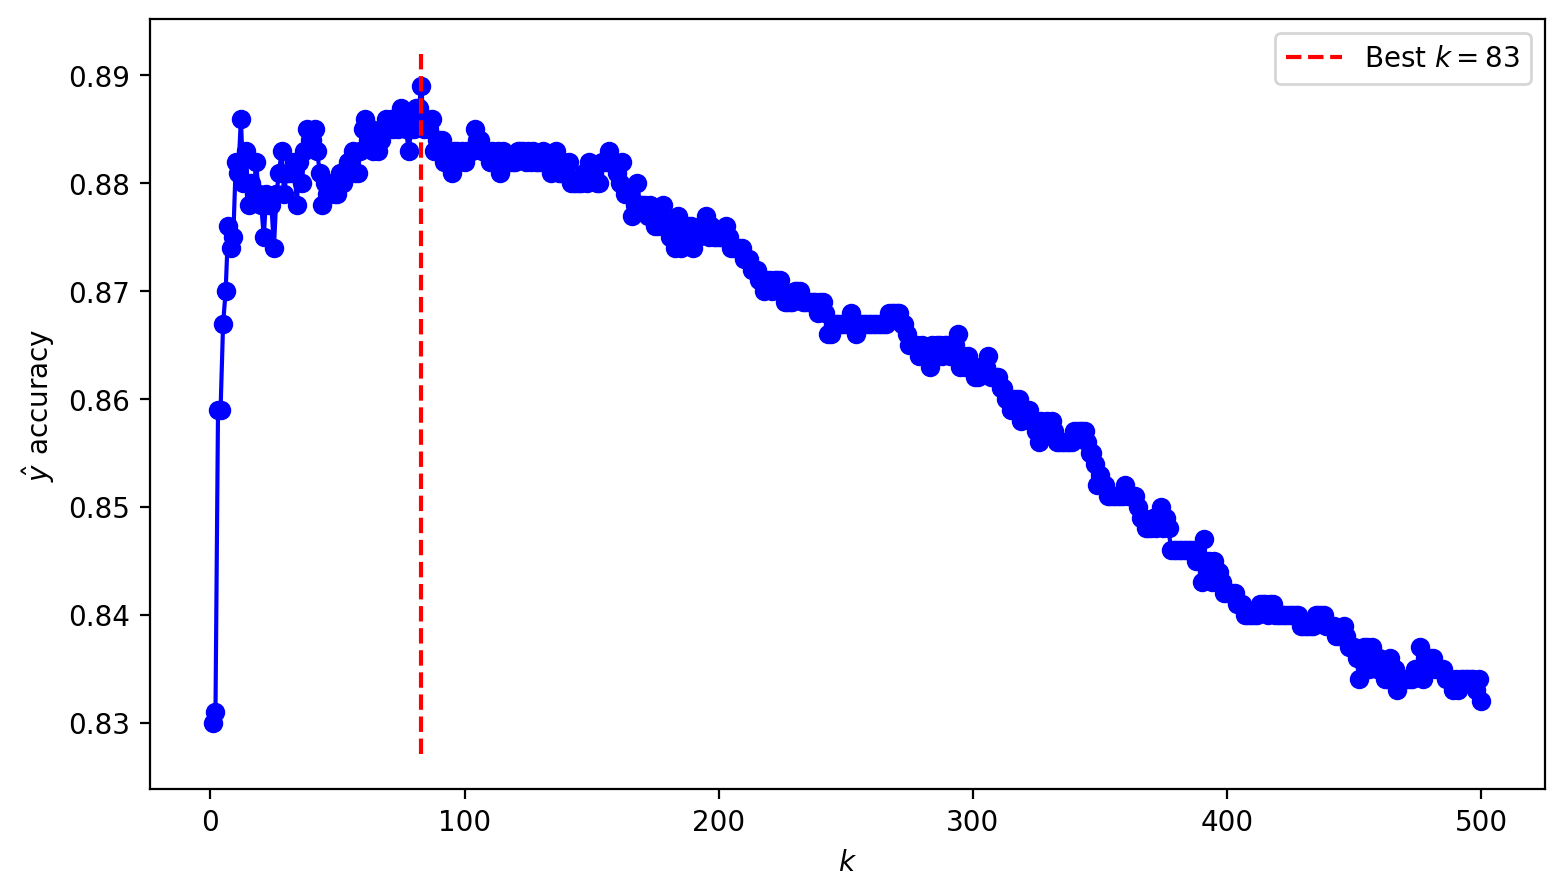

In [530]:
from sklearn.metrics import accuracy_score
MAX = 500

plt.figure(figsize=(9, 5))

ks = list(range(1, MAX+1))

accuracies = []
for k in ks:
    knn = KNeighborsClassifier(k)
    knn.fit(moons_train_x, moons_train_y)
    y_hat = knn.predict(moons_test_x)
    accuracies.append(accuracy_score(moons_test_y, y_hat))

plt.plot(ks, accuracies, 'bo-')

# Plot best K value
best_k = max(zip(ks, accuracies), key=lambda v: v[1])[0]
_, _, ymin, ymax = plt.axis()
plt.vlines(
    x=best_k,
    ymin=ymin,
    ymax=ymax,
    colors='r',
    linestyles='dashed',
    label=f'Best $k={best_k}$',
)

# Set some settings on the plot
plt.xlabel('$k$')
plt.ylabel(r'$\hat y$ accuracy')
plt.legend(loc='upper right')

# Show the thang
plt.show()

### 6c - Visual trend analysis

> What trend do you see in the results?

From $k=1$ to $k=82$, the accuracy of the model increases dramatically. After $k=83$, the accuracy gradually decreases as overfitting (and thus high bias and low variance) occur.

### 6d - Bias and variance

> What values of $k$ represent high bias and which represent high variance?

- High bias: $k=(83, 500]$
- High variance: $k=[1, 83)$

### 6e - Optimal value of $k$

> What is the optimal value of $k$ and why?

$k=83$ is the optimal value, as the accuracy of $\hat y$ is the highest.

### 6f - Model flexibility

> In KNN classifiers, the value of $k$ controls the flexibility of the model. What controls the flexibility of other models?

In linear and polynomial regression, the flexibility of the model is determined by the degree of the fit polynomial. As the degree increases, so does the flexibility, and vice versa.

## 7 - Linear regression and nonlinear transformations

**\[18 points]**

Linear regression can be used to model nonlinear relationships when feature variables are properly transformed to represent the nonlinearities in the data. In this exercise, you're given training and test data contained in files "A2_Q7_train.csv" and "A2_Q7_test.csv" in the "data" folder for this assignment. Your goal is to develop a regression algorithm from the training data that performs well on the test data.

::: {.callout-tip}
Use the scikit learn [LinearRegression](http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) module.
:::

a. Create a scatter plot of your training data.
b. Estimate a linear regression model ($y = a_0 + a_1 x$) for the training data and calculate both the $R^2$ value and mean square error for the fit of that model for the training data. Also provide the equation representing the estimated model (e.g. $y = a_0 + a_1 x$), but with the estimated coefficients inserted. Consider this your baseline model against which you will compare other model options. *Evaluating performance on the training data is not a measure of how well this model would generalize to unseen data. We will evaluate performance on the test data once we see our models fit the training data decently well.*
c. If features can be nonlinearly transformed, a linear model may incorporate those non-linear feature transformation relationships in the training process. From looking at the scatter plot of the training data, choose a transformation of the predictor variable, $x$ that may make sense for this data. This will be a multiple regression model of the form $y = a_0 + a_1 z_1 + a_2 z_2 + \ldots + a_n z_n$. Here $z_i$ could be any transformations of $x$ &mdash; perhaps it's $\frac{1}{x}$, $\log(x)$, $\sin(x)$, $x^k$ (where $k$ is any power of your choosing). Provide the estimated equation for this multiple regression model (e.g. if you chose your predictors to be $z_1 = x$ and $z_2 = \log(x)$, your model would be of the form $y = a_0 + a_1 x + a_2 \log(x)$. Also provide the $R^2$ and mean square error of the fit for the training data.
d. Visualize the model fit to the training data. Using both of the models you created in parts (b) and (c), plot the original data (as a scatter plot) AND the curves representing your models (each as a separate curve) from (b) and (c).
e. Now its time to compare your models and evaluate the generalization performance on held out test data. Using the models above from (b) an (c), apply them to the test data and estimate the $R^2$ and mean square error of the test dataset.
f. Which models perform better on the training data, and which on the test data? Why?
g. Imagine that the test data were significantly different from the training dataset. How might this affect the predictive capability of your model? How would the accuracy of generalization performance be impacted? Why?

To help get you started - here's some code to help you load in the data for this exercise. You'll just need to update the path:

In [346]:
#| output: false
#| code-fold: true
#| code-summary: Starter code
import numpy as np
import pandas as pd

path = './data/'
train = pd.read_csv(path + 'A2_Q7_train.csv')
test = pd.read_csv(path + 'A2_Q7_test.csv')

x_train = train.x.values
y_train = train.y.values

x_test = test.x.values
y_test = test.y.values

**ANSWER**

### 7a - Load and plot the data

> Create a scatter plot of your training data.

In [345]:
train = pd.read_csv(BASE_PATH / 'data' / 'A2_Q7_train.csv')
test = pd.read_csv(BASE_PATH / 'data' / 'A2_Q7_test.csv')

x_train = train.x.values
y_train = train.y.values

x_test = test.x.values
y_test = test.y.values

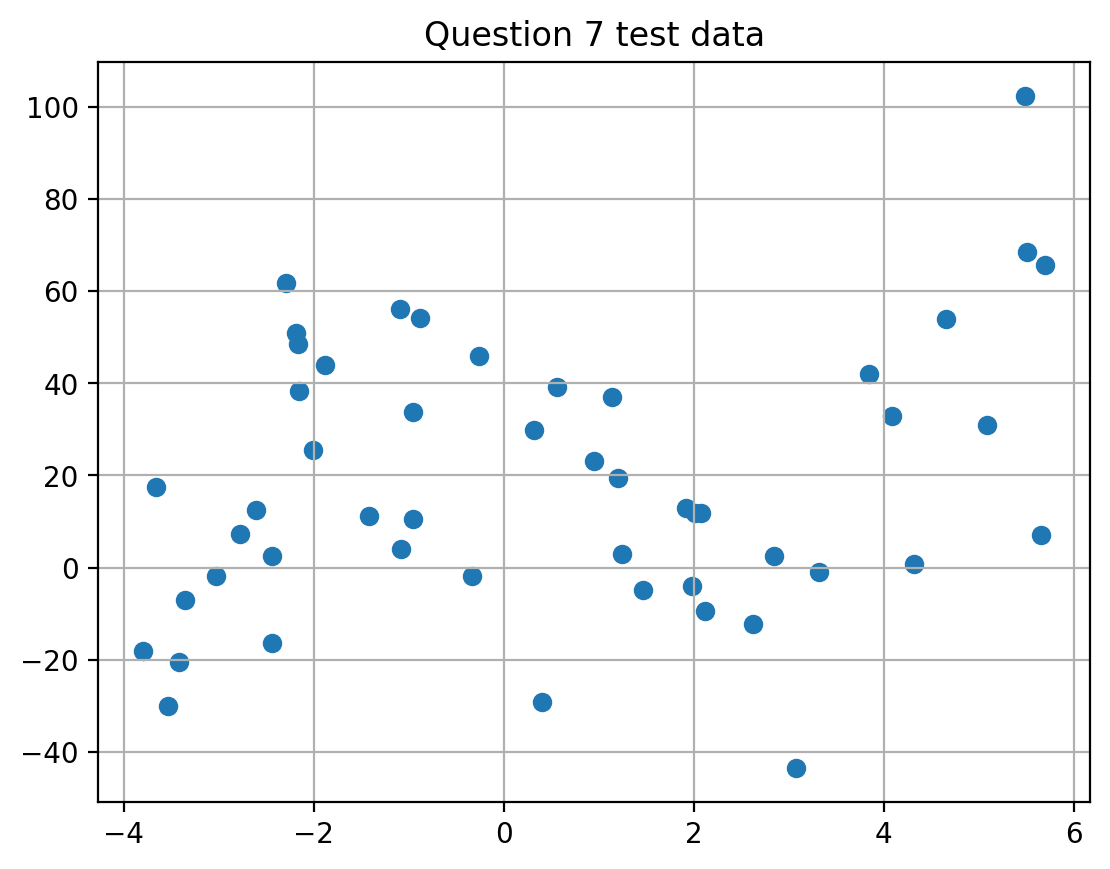

In [364]:
plt.scatter(
    x=x_train,
    y=y_train,
)
plt.title("Question 7 test data")
plt.grid(visible=True)
plt.show()

### 7b - Estimate a linreg model

> Estimate a linear regression model ($y = a_0 + a_1 x$) for the training data and calculate both the $R^2$ value and mean square error for the fit of that model for the training data. Also provide the equation representing the estimated model (e.g. $y = a_0 + a_1 x$), but with the estimated coefficients inserted. Consider this your baseline model against which you will compare other model options.

::: {.callout-note}
Evaluating performance on the training data is not a measure of how well this model would generalize to unseen data. We will evaluate performance on the test data once we see our models fit the training data decently well.
:::

In [531]:
def mse(y_t, y_h):
    assert len(y_t) == len(y_h)
    
    s = sum([(t - h)**2 for t, h in zip(y_t, y_h)])
    
    return (1/len(y_t)) * s


def r2(y_t, y_h):
    assert len(y_t) == len(y_h)
    
    n = len(y_t)
    y_bar = sum(y_t)/len(y_t)
    residual = mse(y_t, y_h) * n
    total = mse(y_t, [y_bar]*n) * n
    
    return 1 - (residual/total)

Estimated linear regression model:

\begin{equation}
    y = 10 + \frac52 x
\end{equation}

In [517]:
part_b = lambda x: 10 + (5/2)*x

print(f'''\
Training error for Part B model:
  MSE: {mse(y_train, part_b(x_train)):.4f}
  R^2: {r2(y_train, part_b(x_train)):.6f}\
''')

Training error for Part B model:
  MSE: 843.9972
  R^2: 0.002732


### 7c - Non-linear transformation

> If features can be nonlinearly transformed, a linear model may incorporate those non-linear feature transformation relationships in the training process. From looking at the scatter plot of the training data, choose a transformation of the predictor variable, $x$, that may make sense for this data. This will be a multiple regression model of the form $y = a_0 + a_1 z_1 + a_2 z_2 + \ldots + a_n z_n$. Here $z_i$ could be any transformations of $x$ &mdash; perhaps it's $\frac{1}{x}$, $\log(x)$, $\sin(x)$, $x^k$ (where $k$ is any power of your choosing). Provide the estimated equation for this multiple regression model (e.g. if you chose your predictors to be $z_1 = x$ and $z_2 = \log(x)$, your model would be of the form $y = a_0 + a_1 x + a_2 \log(x)$. Also provide the $R^2$ and mean square error of the fit for the training data.

- $a_0 = 14$
- $a_1 = -40$
- $z_1 = \sin(x-0.9)$
- $a_2 = 4.5$
- $z_2 = x$

$$
y = 14 - 40\sin(x-0.9) + 4.5x
$$

In [516]:
part_c = lambda x: 14 - 40*np.sin(x-0.9) + 4.5*x

print(f'''\
Training error for Part C model:
  MSE: {mse(y_train, part_c(x_train)):.4f}
  R^2: {r2(y_train, part_c(x_train)):.6f}\
''')

Training error for Part C model:
  MSE: 845.5018
  R^2: 0.000954


### 7d - Visualize it!

> Visualize the model fit to the training data. Using both of the models you created in parts (b) and (c), plot the original data (as a scatter plot) AND the curves representing your models (each as a separate curve) from (b) and (c).

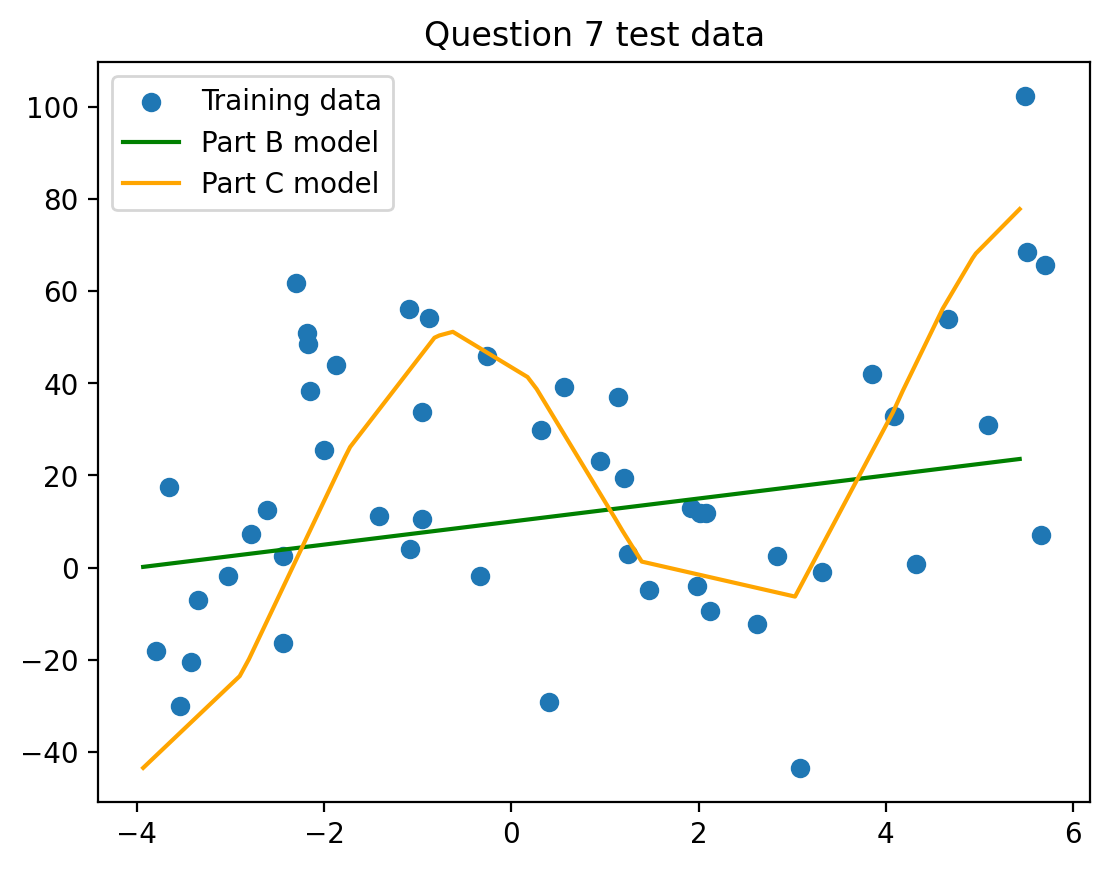

In [514]:
#| code-fold: true
#| code-summary: Show code
# Scatter plot
plt.scatter(
    x=x_train,
    y=y_train,
    label="Training data",
)

# Sort the test data so the curve made by the Part C equation actually
# looks like a curve and not a spiderweb
x_test.sort()

# Model estimate from Part B
plt.plot(x_test, part_b(x_test), label="Part B model", color="g")

# Model estimate from Part C
plt.plot(x_test, part_c(x_test), label="Part C model", color="orange")


plt.title("Question 7 test data")
# plt.grid(visible=True)
plt.legend()
plt.show()

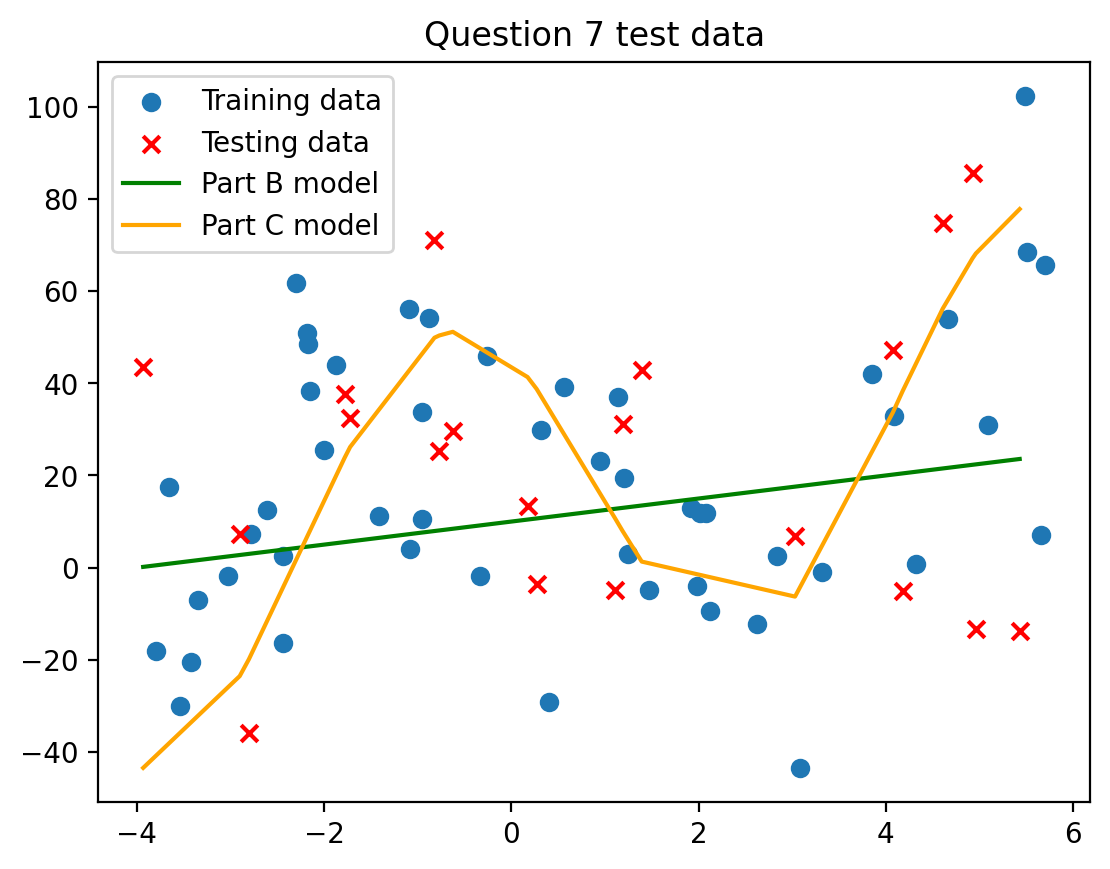

In [513]:
#| code-fold: true
#| code-summary: Show code
plt.scatter(
    x=x_train,
    y=y_train,
    label="Training data",
)
plt.scatter(
    x=x_test,
    y=y_test,
    label="Testing data",
    color="red",
    marker="x"
)

# Sort the test data so the curve made by the Part C equation actually
# looks like a curve and not a spiderweb
x_test.sort()

# Model estimate from Part B
plt.plot(x_test, part_b(x_test), label="Part B model", color="g")

# Model estimate from Part C
plt.plot(x_test, part_c(x_test), label="Part C model", color="orange")


plt.title("Question 7 test data")
# plt.grid(visible=True)
plt.legend()
plt.show()

### 7e - Model test error

> Now its time to compare your models and evaluate the generalization performance on held out test data. Using the models above from (b) an (c), apply them to the test data and estimate the $R^2$ and mean square error of the test dataset.

In [518]:
print(f'''\
Testing error for Part B model:
  MSE: {mse(y_test, part_b(x_test)):.4f}
  R^2: {r2(y_test, part_b(x_test)):.6f}
''')
print(f'''\
Testing error for Part C model:
  MSE: {mse(y_test, part_c(x_test)):.4f}
  R^2: {r2(y_test, part_c(x_test)):.6f}\
''')

Testing error for Part B model:
  MSE: 1129.7665
  R^2: -0.146193

Testing error for Part C model:
  MSE: 1675.7962
  R^2: -0.700162


### 7f - Model performance

> Which models perform better on the training data, and which on the test data? Why?

- Part B:
  - Train:
    - $\text{MSE} = 843.9972$
    - $R^2 = 0.002732$
  - Test:
    - $\text{MSE} = 1129.7665$
    - $R^2 = -0.146193$
- Part C:
  - Train:
    - $\text{MSE} = 845.5018$
    - $R^2 = 0.000954$
  - Test:
    - $\text{MSE} = 1675.7962$
    - $R^2 = -0.700162$

The Part B Model, $y = 10 + \frac52 x$, performed better on the test dataset, with $\text{MSE} = 1129.7665$ and an $R^2 = -0.146193$, as it is more generalized than the Part C non-linear
regression model, $y = 14 - 40\sin(x-0.9) + 4.5x$, which had $\text{MSE} = 1675.7962$ and an $R^2 = -0.700162$. 

However (as you would expect), the Part C Model performed better on the training dataset, as it is much more tightly fit to said dataset, causing some overfitting. It had $\text{MSE} = 845.5018$, just slightly worse than the Part B model's $\text{MSE} = 843.9972$, and an $R^2 = 0.000954$, much better than the Part B model's $R^2 = 0.002732$.

### 7g - Imagine...

> Imagine that the test data were significantly different from the training dataset. How might this affect the predictive capability of your model? How would the accuracy of generalization performance be impacted? Why?

If the test data were siginficantly different from the training dataset, both models would likely have higher errors. However, because of the Part B Model's lower test error, suggesting better generalization, it would likely fare better
than the Part C Model, which is a bit too overfit for good generalization performance.